In [1]:
# %% Imports
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 4)
plt.rcParams['figure.dpi'] = 100

RAW_PATH = '../data/raw.csv'

In [2]:
df_raw = pd.read_csv(RAW_PATH, low_memory=False)

df = (
    df_raw.drop(columns=['hromada', 'raion', 'source'])
        .query('level == "oblast"')
        .drop(columns=['level'])
        .reset_index(drop=True)
)
print(f'Shape: {df.shape}')
df.head()

Shape: (130046, 3)


,oblast,started_at,finished_at
0,Vinnytska oblast,2022-03-15 16:10:34+00:00,2022-03-15 16:50:07+00:00
1,Zhytomyrska oblast,2022-03-15 16:11:25+00:00,2022-03-15 16:54:23+00:00
2,Kirovohradska oblast,2022-03-15 16:15:11+00:00,2022-03-15 16:54:52+00:00
3,Ivano-Frankivska oblast,2022-03-15 16:17:28+00:00,2022-03-15 17:14:18+00:00
4,Lvivska oblast,2022-03-15 16:17:29+00:00,2022-03-15 17:16:23+00:00


In [3]:
# %% Schema & dtypes
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 130046 entries, 0 to 130045
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   oblast       130046 non-null  str  
 1   started_at   130046 non-null  str  
 2   finished_at  130046 non-null  str  
dtypes: str(3)
memory usage: 3.0 MB


In [4]:
# %% Descriptive statistics – all columns
df.describe(include='all').T

,count,unique,top,freq
oblast,130046,25,Donetska oblast,13754
started_at,130046,63590,2024-02-21 10:12:32+00:00,10
finished_at,130046,63395,2024-04-08 11:04:55+00:00,10


In [5]:
# %% Missing-value audit
missing = (
    df.isnull()
    .sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda x: x['missing_count'] / len(df) * 100)
    .sort_values('missing_pct', ascending=False)
)
print(missing[missing['missing_count'] > 0].to_string())

fig, ax = plt.subplots(figsize=(10, max(3, len(missing.query('missing_pct > 0')) * 0.4 + 1)))
cols_with_na = missing[missing['missing_count'] > 0]
if not cols_with_na.empty:
    ax.barh(cols_with_na.index, cols_with_na['missing_pct'], color='steelblue')
    ax.set_xlabel('Missing (%)')
    ax.set_title('Missing values by column')
    ax.axvline(5, color='orange', linestyle='--', linewidth=1, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing values found.')
    plt.close(fig)

Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []
No missing values found.


In [6]:
# %% Parse datetime & set index
df[['started_at', 'finished_at']] = df[['started_at', 'finished_at']].apply(pd.to_datetime, utc=True)
df.dtypes

oblast                         str
started_at     datetime64[us, UTC]
finished_at    datetime64[us, UTC]
dtype: object

In [7]:
# %% Duplicate index check
n_dupes = df.duplicated(subset=['oblast', 'started_at']).sum()
print(f'Duplicate (oblast, started_at) pairs: {n_dupes}')

Duplicate (oblast, started_at) pairs: 64921


In [8]:
# Inspect the duplicates
dupes = df[df.duplicated(subset=['oblast', 'started_at'], keep=False)].sort_values(['oblast', 'started_at'])
print(f'Rows involved: {len(dupes)}')
print(f'Unique oblasts affected: {dupes["oblast"].nunique()}')
dupes.head(10)

Rows involved: 129842
Unique oblasts affected: 25


,oblast,started_at,finished_at
23,Cherkaska oblast,2022-03-16 00:50:06+00:00,2022-03-16 04:42:26+00:00
64944,Cherkaska oblast,2022-03-16 00:50:06+00:00,2022-03-16 04:42:26+00:00
66,Cherkaska oblast,2022-03-17 01:33:50+00:00,2022-03-17 03:10:31+00:00
64987,Cherkaska oblast,2022-03-17 01:33:50+00:00,2022-03-17 03:10:31+00:00
88,Cherkaska oblast,2022-03-17 09:16:09+00:00,2022-03-17 09:16:44+00:00
65009,Cherkaska oblast,2022-03-17 09:16:09+00:00,2022-03-17 09:16:44+00:00
133,Cherkaska oblast,2022-03-18 06:12:37+00:00,2022-03-18 06:56:54+00:00
65054,Cherkaska oblast,2022-03-18 06:12:37+00:00,2022-03-18 06:56:54+00:00
140,Cherkaska oblast,2022-03-18 08:50:19+00:00,2022-03-18 09:29:56+00:00
65061,Cherkaska oblast,2022-03-18 08:50:19+00:00,2022-03-18 09:29:56+00:00


In [9]:
# Note that duplicating values is result of removing "hromada" and "raion" columns. Thus, we can just drop them
df = df.drop_duplicates(subset=['oblast', 'started_at', 'finished_at']).reset_index(drop=True)
print(f'Shape after dedup: {df.shape}')

Shape after dedup: (65125, 3)


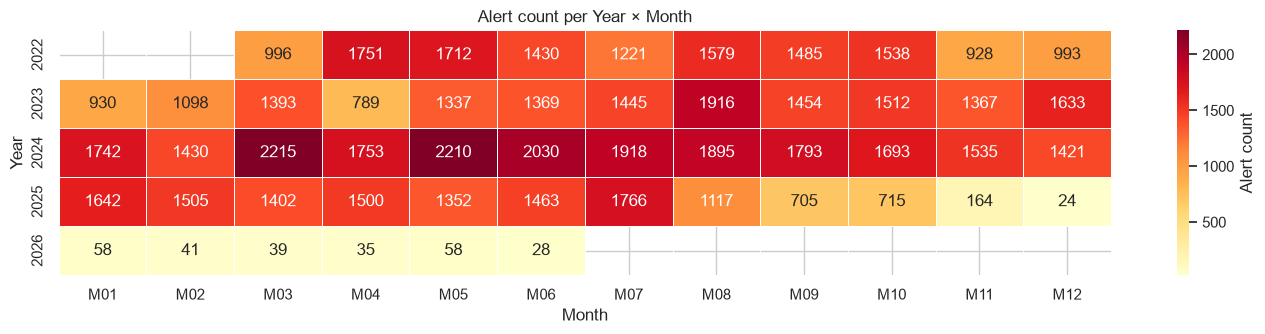

In [10]:
# %% Temporal coverage heatmap
coverage = (
    df.groupby([df['started_at'].dt.year, df['started_at'].dt.month])
    .size()
    .unstack(level=1)
)
coverage.index.name = 'year'
coverage.columns = [f'M{c:02d}' for c in coverage.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(coverage) * 0.5 + 1)))
sns.heatmap(
    coverage, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Alert count'}
)
ax.set_title('Alert count per Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [11]:
# Basic data card
df.head()
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 65125 entries, 0 to 65124
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   oblast       65125 non-null  str                
 1   started_at   65125 non-null  datetime64[us, UTC]
 2   finished_at  65125 non-null  datetime64[us, UTC]
dtypes: datetime64[us, UTC](2), str(1)
memory usage: 1.5 MB


In [12]:
# Save data to new csv
df.to_csv('../data/wraggled.csv', index=False)
print(f'Saved {len(df):,} rows to data/wraggled.csv')

Saved 65,125 rows to data/wraggled.csv


In [13]:
# Check raw data quantity issue
df_raw[['started_at', 'finished_at']] = df_raw[['started_at', 'finished_at']].apply(pd.to_datetime, utc=True)
raw_recent = df_raw[df_raw['started_at'] >= '2025-11-01']
raw_recent_kyiv_city=raw_recent.query('oblast == "Kyiv City"')
print(f'Records from Nov 2025: {len(raw_recent_kyiv_city):,}\n')

# Check raw data quantity issue
recent = df[df['started_at'] >= '2025-11-01']
recent_kyiv_city=recent.query('oblast == "Kyiv City"')
print(f'Records from Nov 2025: {len(recent_kyiv_city):,}\n')

Records from Nov 2025: 444

Records from Nov 2025: 324



In [14]:
print(len(df))                                    # should be 65125
print(df['oblast'].nunique())                     # should be ~25
print(df['oblast'].value_counts().head(10))       # Kyiv City should be one of many

65125
25
oblast
Donetska oblast           6877
Zaporizka oblast          6686
Kharkivska oblast         6504
Dnipropetrovska oblast    5565
Sumska oblast             4078
Poltavska oblast          3993
Mykolaivska oblast        3681
Khersonska oblast         3575
Kirovohradska oblast      3344
Chernihivska oblast       2513
Name: count, dtype: int64


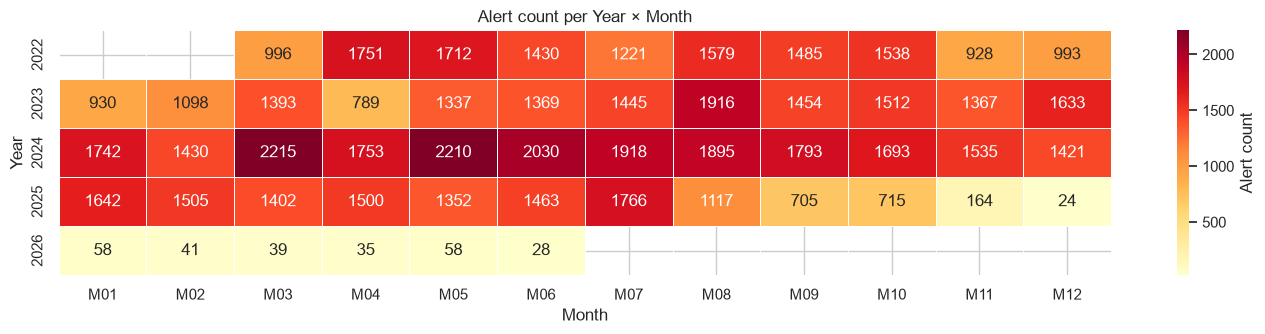

In [15]:
# %% Temporal coverage heatmap

coverage = (
    df.groupby([df['started_at'].dt.year, df['started_at'].dt.month])
    .size()
    .unstack(level=1)
)

coverage.index.name = 'year'
coverage.columns = [f'M{c:02d}' for c in coverage.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(coverage) * 0.5 + 1)))
sns.heatmap(
    coverage, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Alert count'}
)
ax.set_title('Alert count per Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

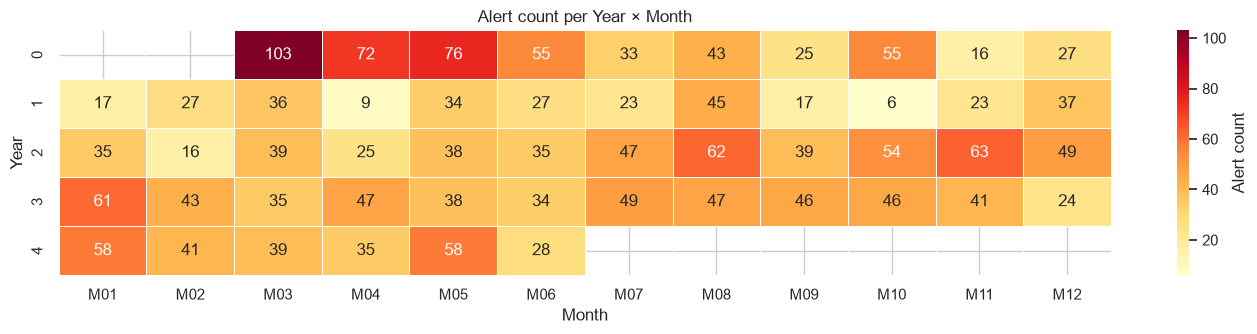

In [16]:
# %% Temporal coverage heatmap
kyiv_df = df.query('oblast == "Kyiv City"')

coverage = (
    kyiv_df.groupby([kyiv_df['started_at'].dt.year, kyiv_df['started_at'].dt.month])
    .size()
    .unstack(level=1)
    .reset_index(drop=True)
)

coverage.index.name = 'year'
coverage.columns = [f'M{c:02d}' for c in coverage.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(coverage) * 0.5 + 1)))
sns.heatmap(
    coverage, annot=True, fmt='.0f', linewidths=0.5,
    cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Alert count'}
)
ax.set_title('Alert count per Year × Month')
ax.set_xlabel('Month')
ax.set_ylabel('Year')
plt.tight_layout()
plt.show()

In [17]:
recent = df[df['started_at'] >= '2025-11-01'].reset_index(drop=True)
kyiv_df = df.query('oblast == "Kyiv City"')
recent_kyiv = kyiv_df[kyiv_df['started_at'] >= '2025-11-01'].reset_index(drop=True)

print(f"Number of air alerts in Kyiv City starting from Nov 2025: {len(recent_kyiv)}")
print(f"Number of air alerts generally starting from Nov 2025: {len(recent)}")

Number of air alerts in Kyiv City starting from Nov 2025: 324
Number of air alerts generally starting from Nov 2025: 447


In [18]:
recent

,oblast,started_at,finished_at
0,Donetska oblast,2025-11-01 00:37:11+00:00,2025-11-01 04:45:47+00:00
1,Zaporizka oblast,2025-11-01 03:04:27+00:00,2025-11-01 04:46:17+00:00
2,Mykolaivska oblast,2025-11-01 04:00:04+00:00,2025-11-01 04:37:51+00:00
3,Mykolaivska oblast,2025-11-01 04:57:29+00:00,2025-11-01 05:32:59+00:00
4,Zaporizka oblast,2025-11-01 05:16:14+00:00,2025-11-01 05:40:22+00:00
...,...,...,...
442,Kyiv City,2026-06-17 21:34:29+00:00,2026-06-17 21:56:49+00:00
443,Kyiv City,2026-06-17 22:21:35+00:00,2026-06-17 23:38:51+00:00
444,Kyiv City,2026-06-18 01:02:05+00:00,2026-06-18 02:42:12+00:00
445,Kyiv City,2026-06-18 04:28:20+00:00,2026-06-18 04:44:54+00:00


In [41]:
raw_recent = df_raw[df_raw['started_at'] >= '2025-11-01']
raw_recent_kyiv = raw_recent.query('oblast == "Kyiv City"').reset_index(drop=True)

print(f"(Raw) Number of air alerts in Kyiv City starting from Nov 2025: {len(raw_recent_kyiv)}")
print(f"(Raw) Number of air alerts generally starting from Nov 2025: {len(raw_recent)}")

(Raw) Number of air alerts in Kyiv City starting from Nov 2025: 444
(Raw) Number of air alerts generally starting from Nov 2025: 89676


In [24]:
df = (
    df_raw.drop(columns=['hromada', 'raion', 'source'])
        .query('level == "oblast"')
        .drop(columns=['level'])
        .reset_index(drop=True)
)
print(f'Shape: {df.shape}')

recent = df[df['started_at'] >= '2025-11-01'].reset_index(drop=True)
recent_kyiv = recent.query('oblast == "Kyiv City"').reset_index(drop=True)

print(f"Number of air alerts in Kyiv City starting from Nov 2025: {len(recent_kyiv)}")
print(f"Number of air alerts generally starting from Nov 2025: {len(recent)}")

Shape: (130046, 3)
Number of air alerts in Kyiv City starting from Nov 2025: 444
Number of air alerts generally starting from Nov 2025: 690


In [37]:
print(len(recent.query('oblast == "Lvivska oblast"')))

2


In [35]:
print(raw_recent['oblast'].value_counts())

oblast
Kharkivska oblast          13946
Dnipropetrovska oblast     11371
Zaporizka oblast            9425
Donetska oblast             7647
Sumska oblast               7290
Odeska oblast               5928
Chernihivska oblast         5796
Poltavska oblast            4177
Khersonska oblast           3832
Kyivska oblast              3617
Mykolaivska oblast          3488
Kirovohradska oblast        2917
Cherkaska oblast            2565
Vinnytska oblast            1383
Zhytomyrska oblast          1256
Lvivska oblast               780
Rivnenska oblast             686
Ivano-Frankivska oblast      673
Zakarpatska oblast           659
Volynska oblast              506
Khmelnytska oblast           502
Kyiv City                    444
Chernivetska oblast          399
Ternopilska oblast           389
Name: count, dtype: int64


In [44]:
df_raw['oblast'].unique()

<StringArray>
[       'Vinnytska oblast',      'Zhytomyrska oblast',
        'Cherkaska oblast',      'Mykolaivska oblast',
    'Kirovohradska oblast',      'Khmelnytska oblast',
          'Kyivska oblast', 'Ivano-Frankivska oblast',
          'Lvivska oblast',        'Rivnenska oblast',
         'Volynska oblast',               'Kyiv City',
      'Ternopilska oblast',     'Chernihivska oblast',
        'Poltavska oblast',         'Donetska oblast',
           'Sumska oblast',  'Dnipropetrovska oblast',
       'Kharkivska oblast',           'Odeska oblast',
        'Zaporizka oblast',     'Chernivetska oblast',
      'Zakarpatska oblast',         'Luhanska oblast',
       'Khersonska oblast']
Length: 25, dtype: str

Seeing that Lvivska oblast had only 2 air alerts made me think that there is something wrong with that data. After doing investigation, I understood that for some oblasts started to appear not on the level of oblast, but on the level of raion, which made me reconsider my approach, which You can see in wraggle_cities.ipynb file